IMPORTS & SEED


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)


DATASET LOADING & PREPROCESSING


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


MODEL DEFINITION

In [ ]:
def build_model(initializer, optimizer):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu',
                              kernel_initializer=initializer,
                              input_shape=(784,)),
        tf.keras.layers.Dense(64, activation='relu',
                              kernel_initializer=initializer),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


PART A — WEIGHT INITIALIZATION COMPARISON

  Random Normal + fixed(SGD Optimizer)

In [ ]:
model_random = build_model(
    tf.keras.initializers.RandomNormal(),
    tf.keras.optimizers.SGD(learning_rate=0.01)
)

history_random = model_random.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4754 - loss: 1.9364 - val_accuracy: 0.8129 - val_loss: 0.7954
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8276 - loss: 0.7012 - val_accuracy: 0.8730 - val_loss: 0.4801
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8725 - loss: 0.4714 - val_accuracy: 0.8922 - val_loss: 0.3893
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8894 - loss: 0.3941 - val_accuracy: 0.9012 - val_loss: 0.3467
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8985 - loss: 0.3548 - val_accuracy: 0.9077 - val_loss: 0.3210
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9047 - loss: 0.3296 - val_accuracy: 0.9137 - val_loss: 0.3026
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9104 - loss: 0.3109 - val_accuracy: 0.9175 - val_loss: 0.2882
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9150 - loss: 0.2958 - val_accuracy: 0.

Xavier Initialization + fixed(SGD Optimizer)


In [ ]:
model_xavier = build_model(
    tf.keras.initializers.GlorotUniform(),
    tf.keras.optimizers.SGD(learning_rate=0.01)
)

history_xavier = model_xavier.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4863 - loss: 1.7148 - val_accuracy: 0.8510 - val_loss: 0.6105
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8573 - loss: 0.5588 - val_accuracy: 0.8940 - val_loss: 0.3992
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8914 - loss: 0.4013 - val_accuracy: 0.9065 - val_loss: 0.3350
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9041 - loss: 0.3447 - val_accuracy: 0.9151 - val_loss: 0.3019
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9113 - loss: 0.3127 - val_accuracy: 0.9209 - val_loss: 0.2800
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9164 - loss: 0.2905 - val_accuracy: 0.9256 - val_loss: 0.2636
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9221 - loss: 0.2733 - val_accuracy: 0.9289 - val_loss: 0.2504
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9265 - loss: 0.2592 - val_accuracy: 0.

He Initialization + fixed(SGD Optimizer)



In [ ]:
model_he = build_model(
    tf.keras.initializers.HeNormal(),
    tf.keras.optimizers.SGD(learning_rate=0.01)
)

history_he = model_he.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4898 - loss: 1.7050 - val_accuracy: 0.8564 - val_loss: 0.5555
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8665 - loss: 0.5170 - val_accuracy: 0.8902 - val_loss: 0.3962
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8906 - loss: 0.3969 - val_accuracy: 0.9015 - val_loss: 0.3430
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9015 - loss: 0.3487 - val_accuracy: 0.9103 - val_loss: 0.3132
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9090 - loss: 0.3193 - val_accuracy: 0.9150 - val_loss: 0.2926
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9157 - loss: 0.2980 - val_accuracy: 0.9198 - val_loss: 0.2765
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9211 - loss: 0.2811 - val_accuracy: 0.9245 - val_loss: 0.2633
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9249 - loss: 0.2669 - val_accuracy: 0.

Initialization Comparison Plots

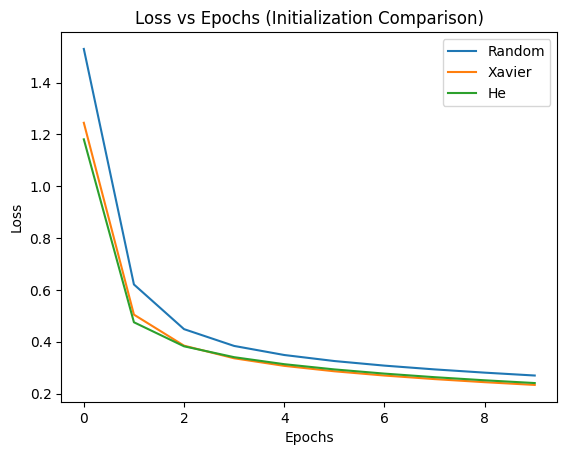

In [ ]:
plt.plot(history_random.history['loss'], label='Random')
plt.plot(history_xavier.history['loss'], label='Xavier')
plt.plot(history_he.history['loss'], label='He')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs (Initialization Comparison)")
plt.legend()
plt.show()


PART B — OPTIMIZER COMPARISON


Adam Optimizer with Best Initialization

In [ ]:
model_adam = build_model(
    tf.keras.initializers.HeNormal(),
    tf.keras.optimizers.Adam()
)

history_adam = model_adam.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8342 - loss: 0.5841 - val_accuracy: 0.9526 - val_loss: 0.1564
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9578 - loss: 0.1487 - val_accuracy: 0.9655 - val_loss: 0.1116
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9707 - loss: 0.1002 - val_accuracy: 0.9706 - val_loss: 0.0928
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9787 - loss: 0.0728 - val_accuracy: 0.9727 - val_loss: 0.0857
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9844 - loss: 0.0551 - val_accuracy: 0.9727 - val_loss: 0.0855
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9884 - loss: 0.0426 - val_accuracy: 0.9723 - val_loss: 0.0860
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9913 - loss: 0.0331 - val_accuracy: 0.9717 - val_loss: 0.0908
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9928 - loss: 0.0269 - val_accuracy: 0.

Optimizer Comparison Plot

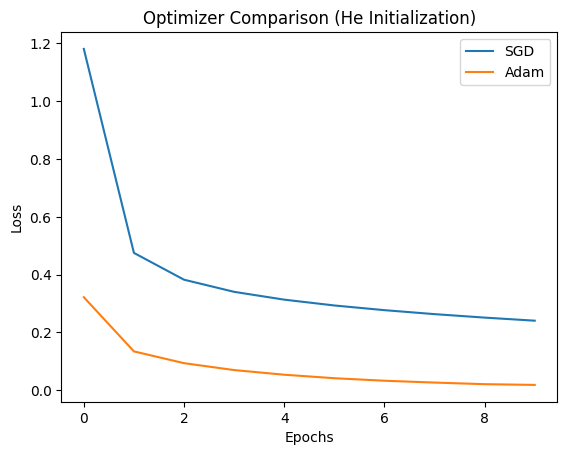

In [ ]:
plt.plot(history_he.history['loss'], label='SGD')
plt.plot(history_adam.history['loss'], label='Adam')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Optimizer Comparison (He Initialization)")
plt.legend()
plt.show()
